In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import os

In [2]:
VIDEO_PATH = "videos/VOT-Woman.mp4"

cap = cv2.VideoCapture(VIDEO_PATH)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"FPS: {fps}")
print(f"Rezolucija: {width} x {height}")
print(f"Ukupno frameova: {total_frames}")
print(f"Trajanje: {total_frames/fps:.2f} sekundi")

cap.release()

FPS: 25.0
Rezolucija: 352 x 288
Ukupno frameova: 597
Trajanje: 23.88 sekundi


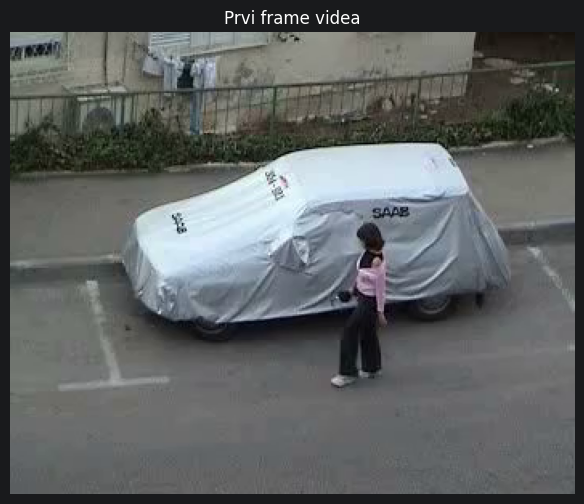

In [3]:
cap = cv2.VideoCapture(VIDEO_PATH)
ret, first_frame = cap.read()
cap.release()

if ret:
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB))
    plt.title("Prvi frame videa")
    plt.axis("off")
    plt.show()
else:
    print("Greška pri čitanju framea!")

In [4]:
# Konverzija u HSV
frame_hsv = cv2.cvtColor(first_frame, cv2.COLOR_BGR2HSV)

# Razdvajanje kanala
B, G, R = cv2.split(first_frame)
H, S, V = cv2.split(frame_hsv)

print("Kanali uspješno razdvojeni!")
print(f"Dimenzije slike: {first_frame.shape}")
print(f"Raspon H kanala: {H.min()} - {H.max()}")
print(f"Raspon S kanala: {S.min()} - {S.max()}")
print(f"Raspon V kanala: {V.min()} - {V.max()}")

Kanali uspješno razdvojeni!
Dimenzije slike: (288, 352, 3)
Raspon H kanala: 0 - 178
Raspon S kanala: 0 - 255
Raspon V kanala: 0 - 255


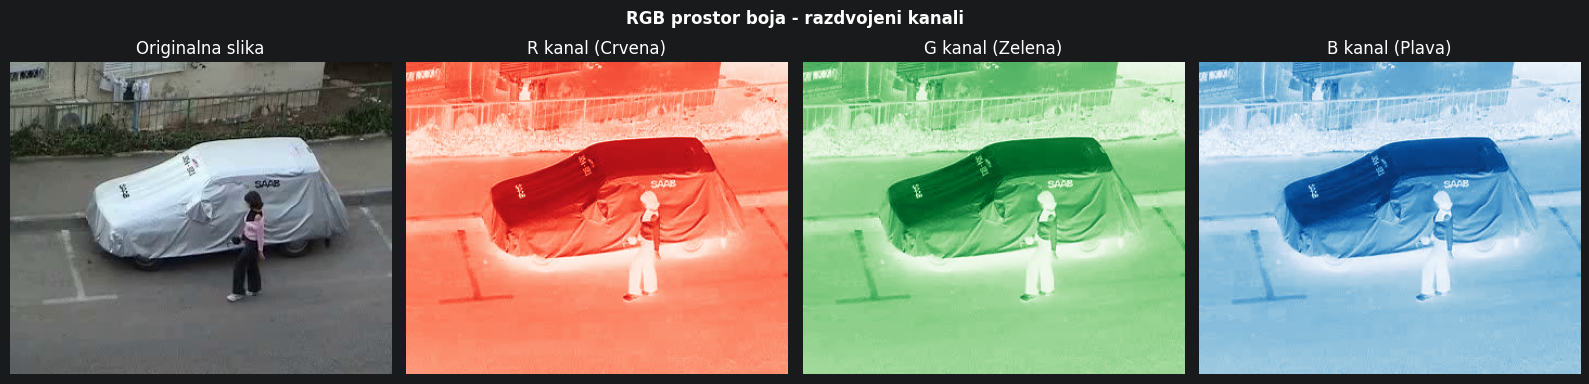

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB))
axes[0].set_title("Originalna slika")

axes[1].imshow(R, cmap='Reds')
axes[1].set_title("R kanal (Crvena)")

axes[2].imshow(G, cmap='Greens')
axes[2].set_title("G kanal (Zelena)")

axes[3].imshow(B, cmap='Blues')
axes[3].set_title("B kanal (Plava)")

for ax in axes:
    ax.axis('off')

plt.suptitle("RGB prostor boja - razdvojeni kanali", fontweight='bold')
plt.tight_layout()
plt.show()

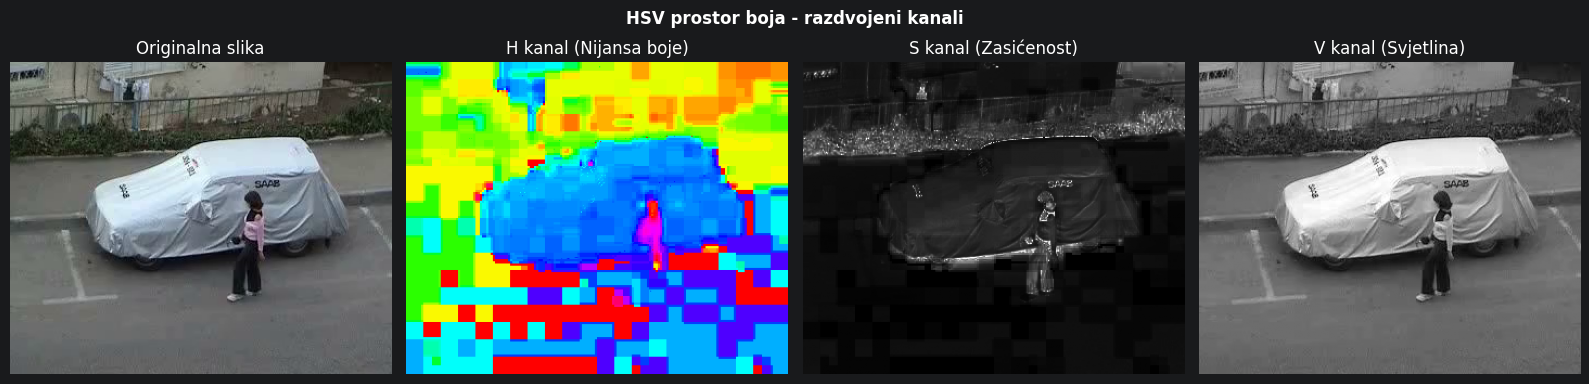

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB))
axes[0].set_title("Originalna slika")

axes[1].imshow(H, cmap='hsv')
axes[1].set_title("H kanal (Nijansa boje)")

axes[2].imshow(S, cmap='gray')
axes[2].set_title("S kanal (Zasićenost)")

axes[3].imshow(V, cmap='gray')
axes[3].set_title("V kanal (Svjetlina)")

for ax in axes:
    ax.axis('off')

plt.suptitle("HSV prostor boja - razdvojeni kanali", fontweight='bold')
plt.tight_layout()
plt.show()

Kliknuti piksel HSV: H=0, S=0, V=79


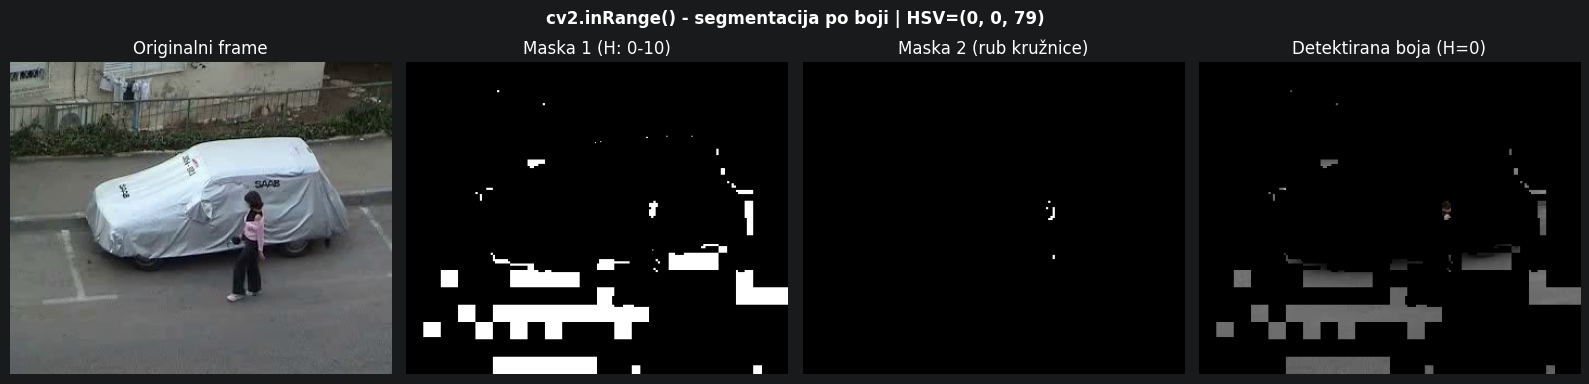

Detektiranih piksela: 9635


In [7]:
# DINAMIČKA SEGMENTACIJA - radi za BILO KOJU kliknutu boju


def get_masks_for_color(hsv_frame, h, s, v, tolerance=10):
    """Gradi masku za bilo koju HSV boju, uključujući crvenu."""

    s_low = max(0,   s - 80)   # malo širi raspon za S i V
    v_low = max(0,   v - 80)

    h_low = h - tolerance
    h_high = h + tolerance

    # Poseban slučaj: crvena boja prelazi rub (0/179)
    if h_low < 0:
        lower1 = np.array([0,          s_low, v_low])
        upper1 = np.array([h_high,     255,   255])
        lower2 = np.array([179 + h_low, s_low, v_low])  # h_low je negativan
        upper2 = np.array([179,         255,   255])
        mask1 = cv2.inRange(hsv_frame, lower1, upper1)
        mask2 = cv2.inRange(hsv_frame, lower2, upper2)
        return cv2.bitwise_or(mask1, mask2), mask1, mask2

    elif h_high > 179:
        lower1 = np.array([h_low,      s_low, v_low])
        upper1 = np.array([179,        255,   255])
        lower2 = np.array([0,          s_low, v_low])
        upper2 = np.array([h_high - 179, 255, 255])
        mask1 = cv2.inRange(hsv_frame, lower1, upper1)
        mask2 = cv2.inRange(hsv_frame, lower2, upper2)
        return cv2.bitwise_or(mask1, mask2), mask1, mask2

    else:
        lower = np.array([h_low,  s_low, v_low])
        upper = np.array([h_high, 255,   255])
        mask  = cv2.inRange(hsv_frame, lower, upper)
        return mask, mask, None



# KLIK - uzmi H, S, V vrijednosti kliknutog piksela


# Npr. kliknuto na koordinatu (x=150, y=200) u first_frame
click_x, click_y = 150, 200

hsv_demo = cv2.cvtColor(first_frame, cv2.COLOR_BGR2HSV)
clicked_hsv = hsv_demo[click_y, click_x]   # [H, S, V]
H, S, V = int(clicked_hsv[0]), int(clicked_hsv[1]), int(clicked_hsv[2])

print(f"Kliknuti piksel HSV: H={H}, S={S}, V={V}")

# IZRAČUN MASKI

mask_demo, mask_demo1, mask_demo2 = get_masks_for_color(hsv_demo, H, S, V, tolerance=10)
result_demo = cv2.bitwise_and(first_frame, first_frame, mask=mask_demo)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB))
axes[0].set_title("Originalni frame")

if mask_demo2 is not None:
    axes[1].imshow(mask_demo1, cmap='gray')
    axes[1].set_title(f"Maska 1 (H: {max(0, H-10)}-{min(179, H+10)})")
    axes[2].imshow(mask_demo2, cmap='gray')
    axes[2].set_title("Maska 2 (rub kružnice)")
else:
    axes[1].imshow(mask_demo1, cmap='gray')
    axes[1].set_title(f"Maska (H: {H-10}-{H+10})")
    axes[2].imshow(np.zeros_like(mask_demo1), cmap='gray')
    axes[2].set_title("Maska 2 (nije potrebna)")

axes[3].imshow(cv2.cvtColor(result_demo, cv2.COLOR_BGR2RGB))
axes[3].set_title(f"Detektirana boja (H={H})")

for ax in axes:
    ax.axis('off')

plt.suptitle(f"cv2.inRange() - segmentacija po boji | HSV=({H}, {S}, {V})", fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Detektiranih piksela: {cv2.countNonZero(mask_demo)}")

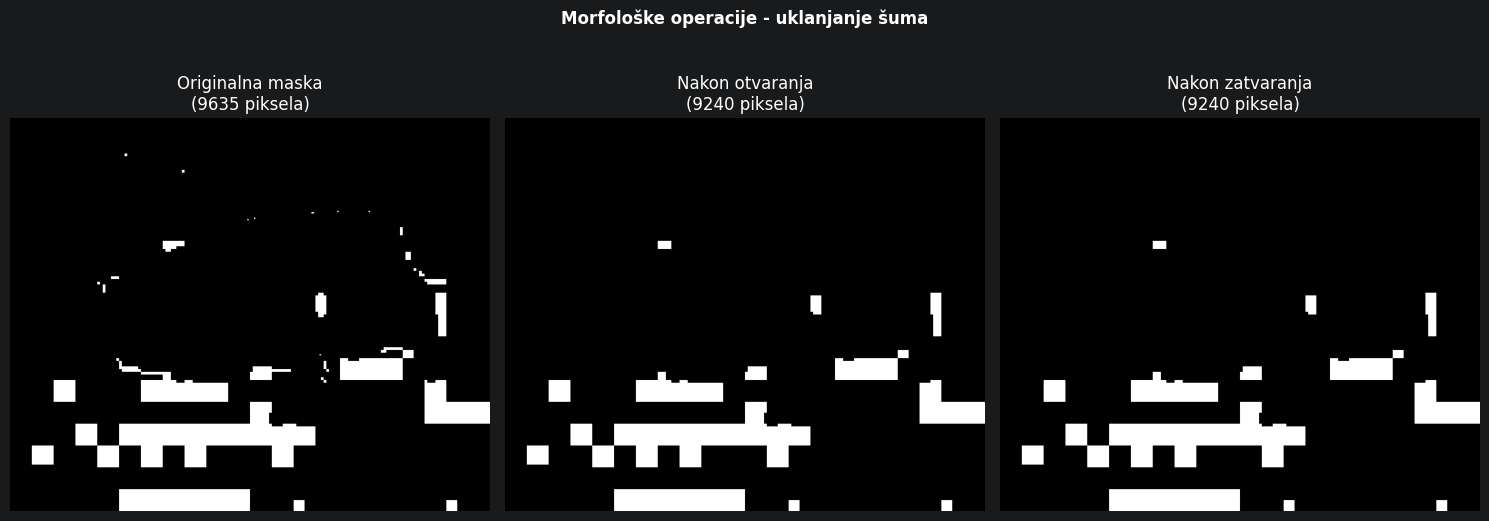

In [8]:
kernel = np.ones((5, 5), np.uint8)

# Otvaranje: uklanja sitni šum (erozija → dilatacija)
mask_opened = cv2.morphologyEx(mask_demo, cv2.MORPH_OPEN, kernel)

# Zatvaranje: popunjava rupe unutar objekta (dilatacija → erozija)
mask_closed = cv2.morphologyEx(mask_opened, cv2.MORPH_CLOSE, kernel)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
axes[0].imshow(mask_demo,   cmap='gray')
axes[0].set_title(f"Originalna maska\n({cv2.countNonZero(mask_demo)} piksela)")
axes[1].imshow(mask_opened, cmap='gray')
axes[1].set_title(f"Nakon otvaranja\n({cv2.countNonZero(mask_opened)} piksela)")
axes[2].imshow(mask_closed, cmap='gray')
axes[2].set_title(f"Nakon zatvaranja\n({cv2.countNonZero(mask_closed)} piksela)")

for ax in axes:
    ax.axis('off')

plt.suptitle("Morfološke operacije - uklanjanje šuma", fontweight='bold')
plt.tight_layout()
plt.show()

Pronađeno kontura: 13
Površina najveće konture: 3497 px²
Središte lopte: (140, 234)


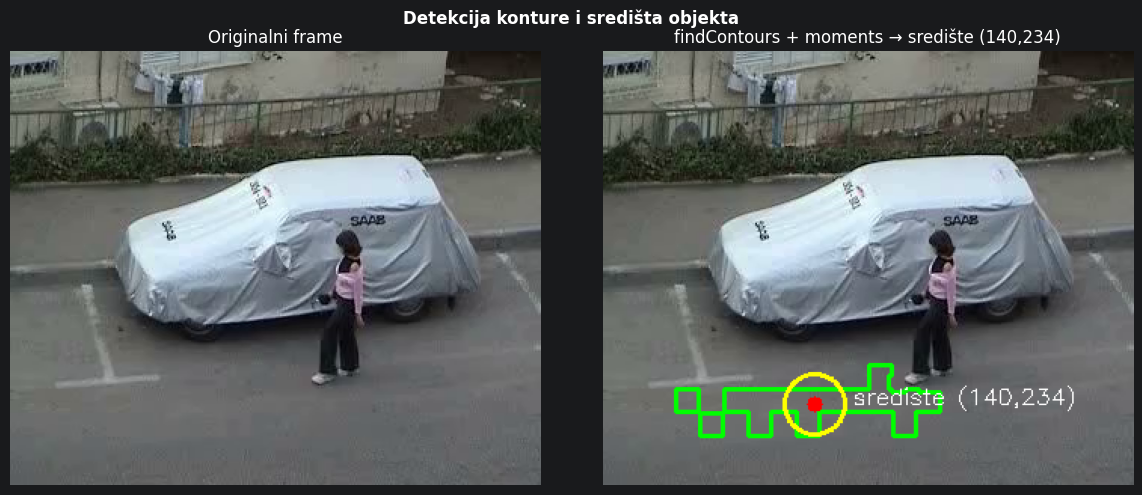

In [9]:
# findContours pronalazi rubove bijelih područja u masci
contours, _ = cv2.findContours(mask_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(f"Pronađeno kontura: {len(contours)}")

frame_demo = first_frame.copy()

if contours:
    # Najveća kontura = lopta
    largest = max(contours, key=cv2.contourArea)
    print(f"Površina najveće konture: {cv2.contourArea(largest):.0f} px²")

    # moments() → središte objekta
    # Središte = (m10/m00, m01/m00) → ponderirani prosjek pozicija piksela
    M = cv2.moments(largest)
    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        print(f"Središte lopte: ({cx}, {cy})")

    cv2.drawContours(frame_demo, [largest], -1, (0, 255, 0), 2)
    cv2.circle(frame_demo, (cx, cy), 5,  (0, 0, 255), -1)
    cv2.circle(frame_demo, (cx, cy), 20, (0, 255, 255), 2)
    cv2.putText(frame_demo, f"srediste ({cx},{cy})", (cx+25, cy),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB))
axes[0].set_title("Originalni frame")
axes[1].imshow(cv2.cvtColor(frame_demo, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"findContours + moments → središte ({cx},{cy})")
for ax in axes:
    ax.axis('off')

plt.suptitle("Detekcija konture i središta objekta", fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# Globalne varijable
selected_hsv = None
selected_pixel_bgr = None

def mouse_callback(event, x, y, flags, param):
    global selected_hsv, selected_pixel_bgr

    if event == cv2.EVENT_LBUTTONDOWN:
        selected_pixel_bgr = param[y, x]

        pixel = np.uint8([[selected_pixel_bgr]])
        pixel_hsv = cv2.cvtColor(pixel, cv2.COLOR_BGR2HSV)
        selected_hsv = pixel_hsv[0][0]

        print(f"Kliknuto: ({x}, {y})")
        print(f"BGR: {selected_pixel_bgr}")
        print(f"HSV: H={selected_hsv[0]}, S={selected_hsv[1]}, V={selected_hsv[2]}")

print("Callback definiran!")

Callback definiran!


In [11]:
# UPUTA: Kada se otvori prozor, klikni na boju
#        (izbjegni bijele točke i rubove gdje je sjena)
#        Zatim pritisni ENTER

cap = cv2.VideoCapture(VIDEO_PATH)
ret, first_frame = cap.read()
cap.release()

display = first_frame.copy()
cv2.putText(display, "KLIKNI NA BOJU", (10, 25),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
cv2.putText(display, "Izbjegni bijele tocke i rubove!", (10, 50),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 165, 255), 1)
cv2.putText(display, "Pritisni ENTER za potvrdu", (10, 75),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

cv2.namedWindow("Odaberi objekt - klikni misem")
cv2.setMouseCallback("Odaberi objekt - klikni misem", mouse_callback, first_frame)

while True:
    show = display.copy()
    if selected_hsv is not None:
        # Prikaži odabranu boju kao pravokutnik
        color_bgr = selected_pixel_bgr.tolist()
        cv2.rectangle(show, (10, 90), (160, 120), color_bgr, -1)
        cv2.putText(show, f"HSV: {selected_hsv}", (10, 140),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

    cv2.imshow("Odaberi objekt - klikni misem", show)
    key = cv2.waitKey(1) & 0xFF
    if key == 13:  # ENTER
        break

cv2.destroyAllWindows()

if selected_hsv is not None:
    print(f"\nOdabrana HSV vrijednost: {selected_hsv}")
else:
    # FALLBACK - ako korisnik nije kliknuo, uzmi središnji piksel prvog framea
    h, w = first_frame.shape[:2]
    center_pixel_bgr = first_frame[h // 2, w // 2]
    center_pixel_hsv = cv2.cvtColor(
        center_pixel_bgr.reshape(1, 1, 3), cv2.COLOR_BGR2HSV
    )[0][0]

    selected_hsv = center_pixel_hsv
    selected_pixel_bgr = center_pixel_bgr
    print("Nije odabrana boja! Koristi se središnji piksel prvog framea kao fallback.")
    print(f"Fallback HSV: {selected_hsv}")

Kliknuto: (229, 151)
BGR: [157 131 160]
HSV: H=153, S=46, V=160

Odabrana HSV vrijednost: [153  46 160]


In [12]:
def calculate_hsv_range(hsv_value, h_tolerance=20, s_tolerance=80, v_tolerance=80):
    """
    Automatski izračunava HSV raspon oko odabrane vrijednosti.
    Veća tolerancija = detekcija više nijansi (ali i više šuma).
    Manji tolerancija = preciznija detekcija (ali može gubiti objekt).
    """
    h = int(hsv_value[0])
    s = int(hsv_value[1])
    v = int(hsv_value[2])

    lower = np.array([max(0,   h - h_tolerance),
                      max(0,   s - s_tolerance),
                      max(0,   v - v_tolerance)])

    upper = np.array([min(179, h + h_tolerance),
                      min(255, s + s_tolerance),
                      min(255, v + v_tolerance)])

    ranges = [(lower, upper)]

    # Poseban slučaj: crvena prelazi granicu 0/179
    if h - h_tolerance < 0:
        lower2 = np.array([179 + (h - h_tolerance), lower[1], lower[2]])
        upper2 = np.array([179, upper[1], upper[2]])
        ranges.append((lower2, upper2))

    if h + h_tolerance > 179:
        lower2 = np.array([0, lower[1], lower[2]])
        upper2 = np.array([(h + h_tolerance) - 179, upper[1], upper[2]])
        ranges.append((lower2, upper2))

    return ranges


if selected_hsv is not None:
    hsv_ranges = calculate_hsv_range(selected_hsv)
    print("Izračunati HSV rasponi:")
    for i, (low, high) in enumerate(hsv_ranges):
        print(f"  Raspon {i+1}: H={low[0]}-{high[0]}, "
              f"S={low[1]}-{high[1]}, V={low[2]}-{high[2]}")
else:
    print("Prvo odaberi boju u ćeliji 12!")

Izračunati HSV rasponi:
  Raspon 1: H=133-173, S=0-126, V=80-240


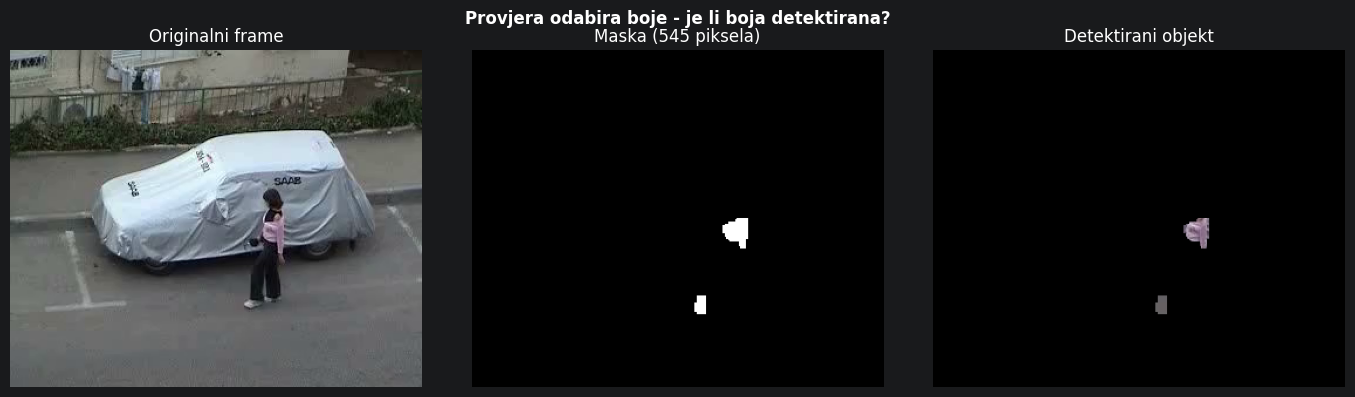

Detektiranih piksela: 545
OK! Možeš pokrenuti praćenje.


In [13]:
hsv_check = cv2.cvtColor(first_frame, cv2.COLOR_BGR2HSV)

final_mask = np.zeros(hsv_check.shape[:2], dtype=np.uint8)
for (low, high) in hsv_ranges:
    m = cv2.inRange(hsv_check, low, high)
    final_mask = cv2.bitwise_or(final_mask, m)

kernel = np.ones((5, 5), np.uint8)
final_mask = cv2.morphologyEx(final_mask, cv2.MORPH_OPEN,  kernel)
final_mask = cv2.morphologyEx(final_mask, cv2.MORPH_CLOSE, kernel)

result_check = cv2.bitwise_and(first_frame, first_frame, mask=final_mask)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(cv2.cvtColor(first_frame,   cv2.COLOR_BGR2RGB))
axes[0].set_title("Originalni frame")
axes[1].imshow(final_mask, cmap='gray')
axes[1].set_title(f"Maska ({cv2.countNonZero(final_mask)} piksela)")
axes[2].imshow(cv2.cvtColor(result_check, cv2.COLOR_BGR2RGB))
axes[2].set_title("Detektirani objekt")
for ax in axes:
    ax.axis('off')

plt.suptitle("Provjera odabira boje - je li boja detektirana?", fontweight='bold')
plt.tight_layout()
plt.show()

pixel_count = cv2.countNonZero(final_mask)
print(f"Detektiranih piksela: {pixel_count}")
if pixel_count < 100:
    print("PREMALO piksela! Ponovi odabir boje i klikni točno na objekt koji želiš pratiti.")
elif pixel_count > 8000:
    print("PREVIŠE piksela! Ima šuma. Probaj smanjiti toleranciju (uži HSV raspon).")
else:
    print("OK! Možeš pokrenuti praćenje.")

In [14]:
# Pokreće se prozor gdje gledaš praćenje u realnom vremenu
# Istovremeno se sprema video s putanjom

MIN_AREA = 200
trajectory_live = deque(maxlen=64)

OUTPUT_DIR = "videos"
os.makedirs(OUTPUT_DIR, exist_ok=True)

existing = [f for f in os.listdir(OUTPUT_DIR) if f.startswith("output_tracker_") and f.endswith(".mp4")]
num = len(existing) + 1
OUTPUT_PATH = os.path.join(OUTPUT_DIR, f"output_tracker_{num}.mp4")

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(OUTPUT_PATH, fourcc, fps, (width, height))

cap = cv2.VideoCapture(VIDEO_PATH)
frame_count  = 0
lost_count   = 0

print("Pokrenuto praćenje uzivo...")
print(">> Pritisni Q za prijevremeno zaustavljanje <<")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # Kreiranje kombinirane maske
    mask = np.zeros(hsv.shape[:2], dtype=np.uint8)
    for (low, high) in hsv_ranges:
        m = cv2.inRange(hsv, low, high)
        mask = cv2.bitwise_or(mask, m)

    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    center = None
    if contours:
        largest = max(contours, key=cv2.contourArea)
        if cv2.contourArea(largest) > MIN_AREA:
            M = cv2.moments(largest)
            if M["m00"] != 0:
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                center = (cx, cy)

                cv2.drawContours(frame, [largest], -1, (0, 255, 0), 2)
                cv2.circle(frame, center, 5,  (0, 0, 255),   -1)
                cv2.circle(frame, center, 20, (0, 255, 255),  2)
                cv2.putText(frame, f"({cx},{cy})", (cx + 15, cy),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)

    if center is None:
        lost_count += 1

    trajectory_live.append(center)

    # Crtaj putanju (starije točke su tanje)
    for i in range(1, len(trajectory_live)):
        if trajectory_live[i-1] is None or trajectory_live[i] is None:
            continue
        thickness = int(np.sqrt(64 / float(i + 1)) * 2)
        cv2.line(frame, trajectory_live[i-1], trajectory_live[i], (0, 165, 255), thickness)

    # HUD - informacije na ekranu
    cv2.putText(frame, f"Frame:   {frame_count}/{total_frames}", (10, 20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1)
    cv2.putText(frame, f"Status:  {'PRATI' if center else 'IZGUBLJEN'}",  (10, 38),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45,
                (0, 255, 0) if center else (0, 0, 255), 1)
    cv2.putText(frame, f"Izgub.:  {lost_count} frameova", (10, 56),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 165, 255), 1)
    cv2.putText(frame, "Q = izlaz", (10, height - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (180, 180, 180), 1)

    cv2.imshow("Pracenje objekta - uzivo", frame)
    out.write(frame)

    key = cv2.waitKey(40) & 0xFF
    if key == ord('q'):
        break

cap.release()
out.release()
cv2.destroyAllWindows()

print(f"\nZavršeno!")
print(f"Ukupno frameova:    {frame_count}")
print(f"Izgubljenih:        {lost_count} ({lost_count/frame_count*100:.1f}%)")
print(f"Uspješno praćeno:   {frame_count - lost_count} ({(frame_count-lost_count)/frame_count*100:.1f}%)")
print(f"Video spremljen:    {OUTPUT_PATH}")

Pokrenuto praćenje uzivo...
>> Pritisni Q za prijevremeno zaustavljanje <<

Završeno!
Ukupno frameova:    597
Izgubljenih:        252 (42.2%)
Uspješno praćeno:   345 (57.8%)
Video spremljen:    videos\output_tracker_1.mp4


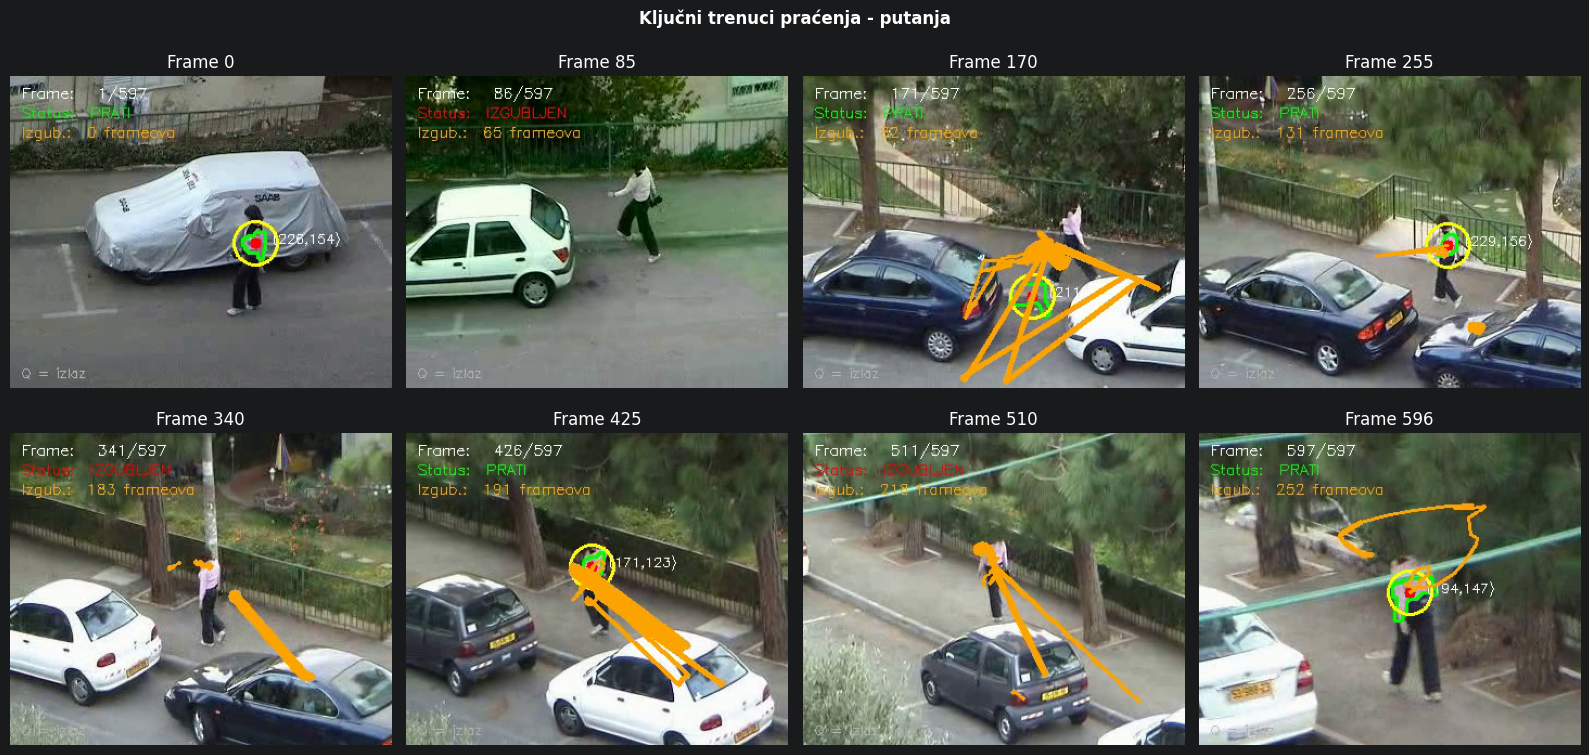

In [15]:
cap_out = cv2.VideoCapture(OUTPUT_PATH)
total_out = int(cap_out.get(cv2.CAP_PROP_FRAME_COUNT))

key_frames = []
for i in range(8):
    pos = int((i / 7) * (total_out - 1))
    cap_out.set(cv2.CAP_PROP_POS_FRAMES, pos)
    ret, f = cap_out.read()
    if ret:
        key_frames.append((pos, f))

cap_out.release()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flat

for i, (pos, f) in enumerate(key_frames):
    axes[i].imshow(cv2.cvtColor(f, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f"Frame {pos}")
    axes[i].axis('off')

plt.suptitle("Ključni trenuci praćenja - putanja", fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# Analiza koliko dobro algoritam prati objekt
# kroz promjene osvjetljenja, brzinu i šum

cap_eval = cv2.VideoCapture(VIDEO_PATH)
trajectory_eval = deque(maxlen=64)

frame_results = []
frame_count_eval = 0

while True:
    ret, frame = cap_eval.read()
    if not ret:
        break

    frame_count_eval += 1
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    mask = np.zeros(hsv.shape[:2], dtype=np.uint8)
    for (low, high) in hsv_ranges:
        m = cv2.inRange(hsv, low, high)
        mask = cv2.bitwise_or(mask, m)

    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    center = None
    area   = 0
    if contours:
        largest = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(largest)
        if area > MIN_AREA:
            M = cv2.moments(largest)
            if M["m00"] != 0:
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                center = (cx, cy)

    trajectory_eval.append(center)

    # Brzina: udaljenost između zadnje dvije detektirane točke
    speed = 0
    if len(trajectory_eval) >= 2:
        p1 = trajectory_eval[-1]
        p2 = trajectory_eval[-2]
        if p1 is not None and p2 is not None:
            speed = np.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

    frame_results.append({
        'frame':    frame_count_eval,
        'detected': center is not None,
        'area':     area,
        'speed':    speed,
        'center':   center
    })

cap_eval.release()

# Statistike
detected    = [r for r in frame_results if r['detected']]
not_detected = [r for r in frame_results if not r['detected']]
speeds      = [r['speed'] for r in detected if r['speed'] > 0]
areas       = [r['area']  for r in detected]

print("=" * 50)
print("       EVALUACIJA STABILNOSTI PRAĆENJA")
print("=" * 50)
print(f"Ukupno frameova:        {frame_count_eval}")
print(f"Detektirano:            {len(detected)} ({len(detected)/frame_count_eval*100:.1f}%)")
print(f"Nije detektirano:       {len(not_detected)} ({len(not_detected)/frame_count_eval*100:.1f}%)")
print(f"Prosječna brzina:       {np.mean(speeds):.1f} px/frame")
print(f"Maksimalna brzina:      {np.max(speeds):.1f} px/frame")
print(f"Prosječna površina:     {np.mean(areas):.0f} px²")
print("=" * 50)

       EVALUACIJA STABILNOSTI PRAĆENJA
Ukupno frameova:        597
Detektirano:            345 (57.8%)
Nije detektirano:       252 (42.2%)
Prosječna brzina:       17.0 px/frame
Maksimalna brzina:      186.0 px/frame
Prosječna površina:     465 px²


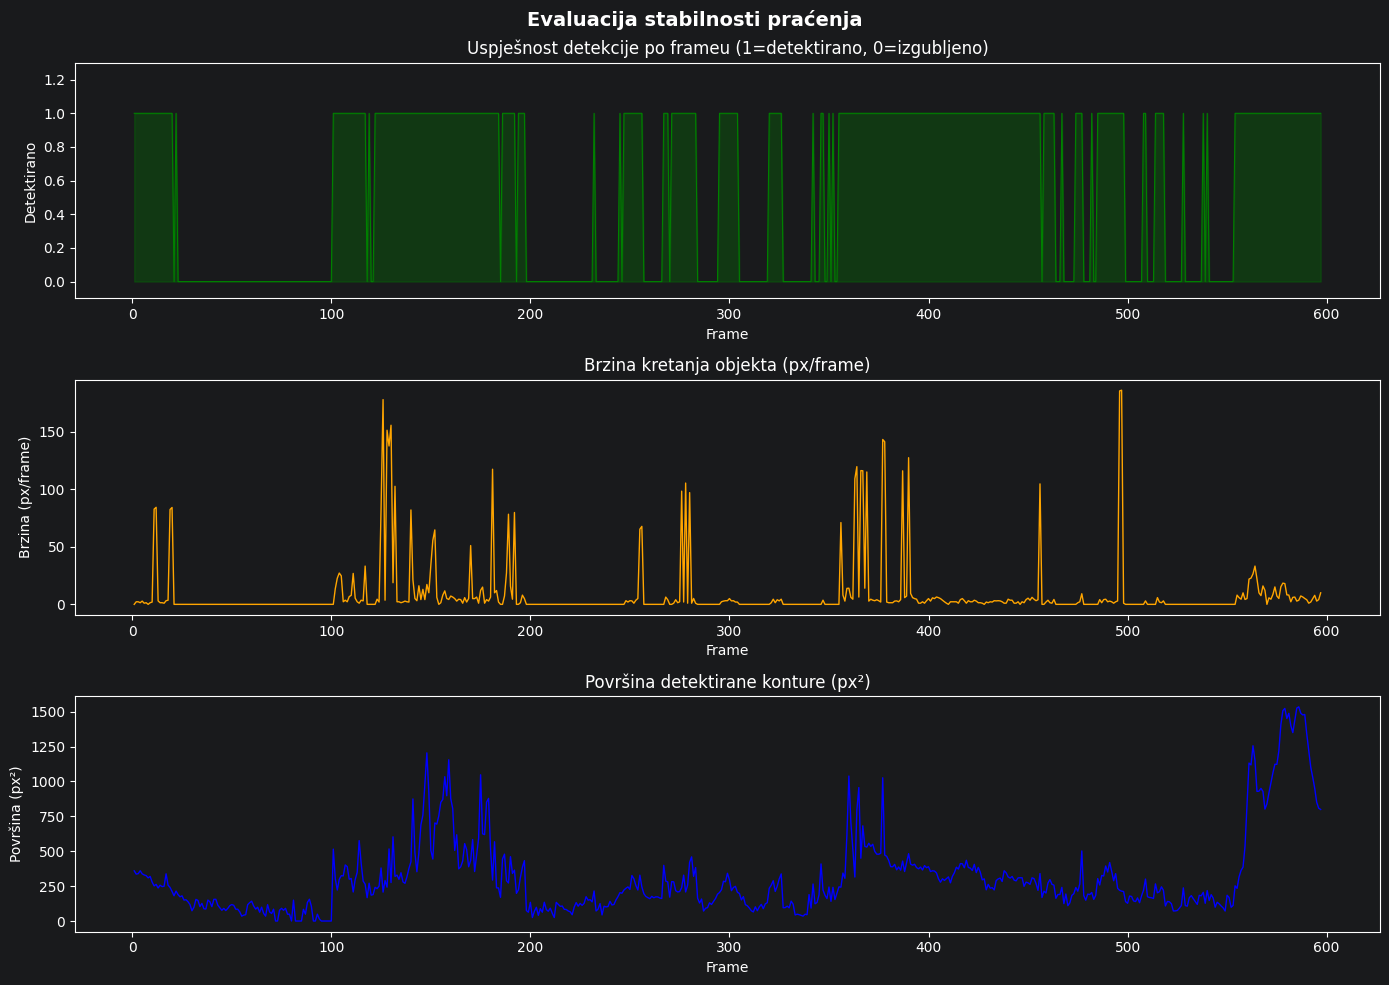

In [17]:
frames_list   = [r['frame']             for r in frame_results]
detected_list = [1 if r['detected'] else 0 for r in frame_results]
speed_list    = [r['speed']             for r in frame_results]
area_list     = [r['area']              for r in frame_results]

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Graf 1: Detekcija po frameu
axes[0].plot(frames_list, detected_list, color='green', linewidth=0.8)
axes[0].fill_between(frames_list, detected_list, alpha=0.3, color='green')
axes[0].set_title("Uspješnost detekcije po frameu (1=detektirano, 0=izgubljeno)")
axes[0].set_ylabel("Detektirano")
axes[0].set_ylim(-0.1, 1.3)
axes[0].set_xlabel("Frame")

# Graf 2: Brzina kretanja
axes[1].plot(frames_list, speed_list, color='orange', linewidth=1)
axes[1].set_title("Brzina kretanja objekta (px/frame)")
axes[1].set_ylabel("Brzina (px/frame)")
axes[1].set_xlabel("Frame")

# Graf 3: Površina konture
axes[2].plot(frames_list, area_list, color='blue', linewidth=1)
axes[2].set_title("Površina detektirane konture (px²)")
axes[2].set_ylabel("Površina (px²)")
axes[2].set_xlabel("Frame")

plt.suptitle("Evaluacija stabilnosti praćenja", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()